### 1. Import Required Libraries

* Setup connection with SnowFlake

In [5]:
file_path = "NVIDIA_STOCK.csv" 


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1697 entries, 2018-01-02 to 2024-09-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  1697 non-null   float64
 1   Close      1697 non-null   float64
 2   High       1697 non-null   float64
 3   Low        1697 non-null   float64
 4   Open       1697 non-null   float64
 5   Volume     1697 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 92.8 KB
None

Dataset Description:
         Adj Close        Close         High          Low         Open  \
count  1697.000000  1697.000000  1697.000000  1697.000000  1697.000000   
mean     24.797593    24.828411    25.295239    24.315422    24.823341   
std      29.221442    29.216014    29.811740    28.570804    29.240504   
min       3.151430     3.177000     3.249500     3.111500     3.162250   
25%       6.113620     6.161750     6.250000     6.064250     6.166250   
50%      13.985092 

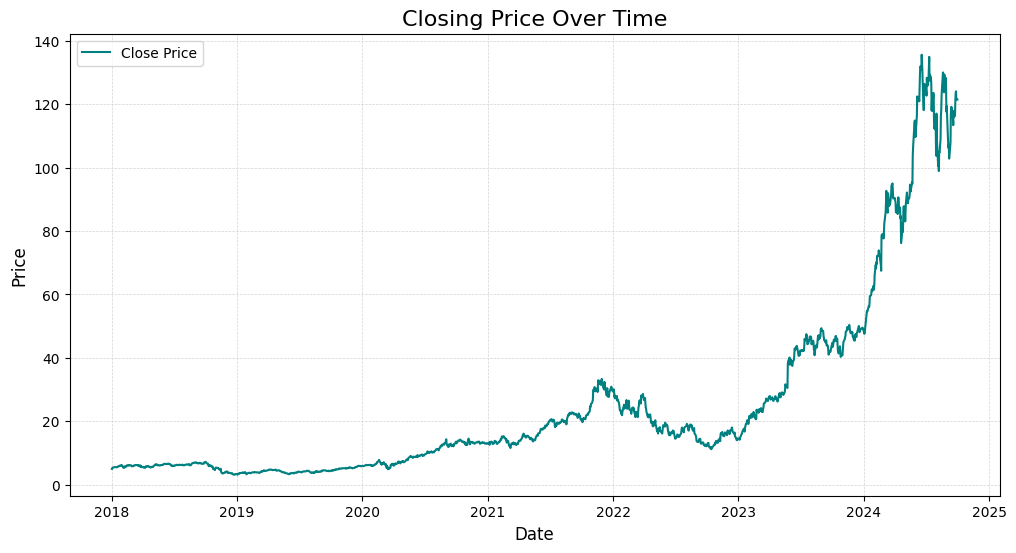

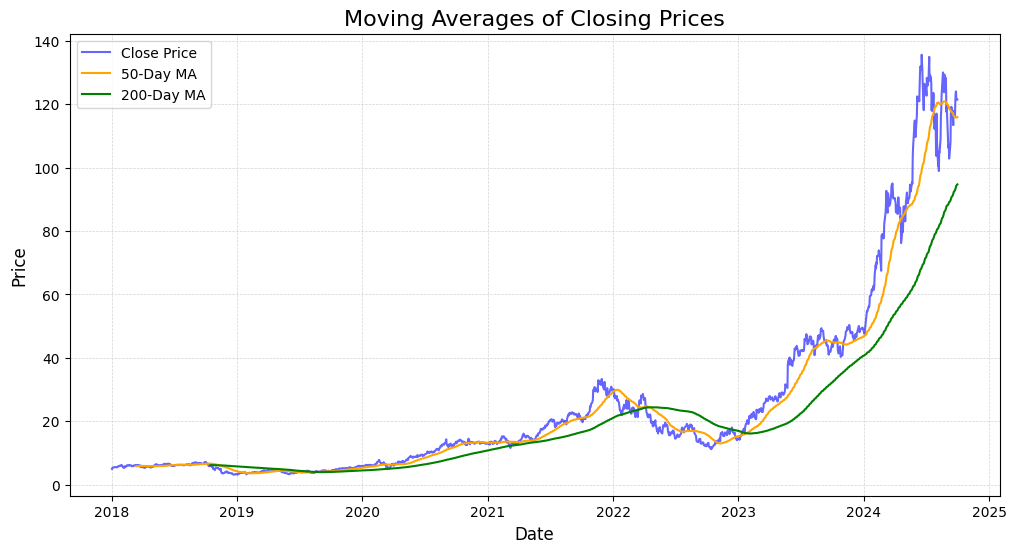

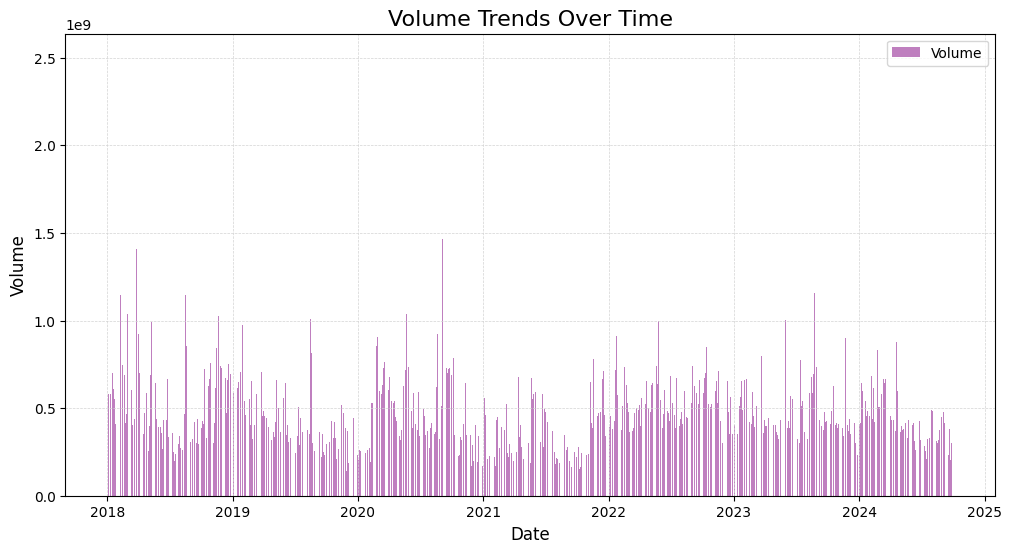

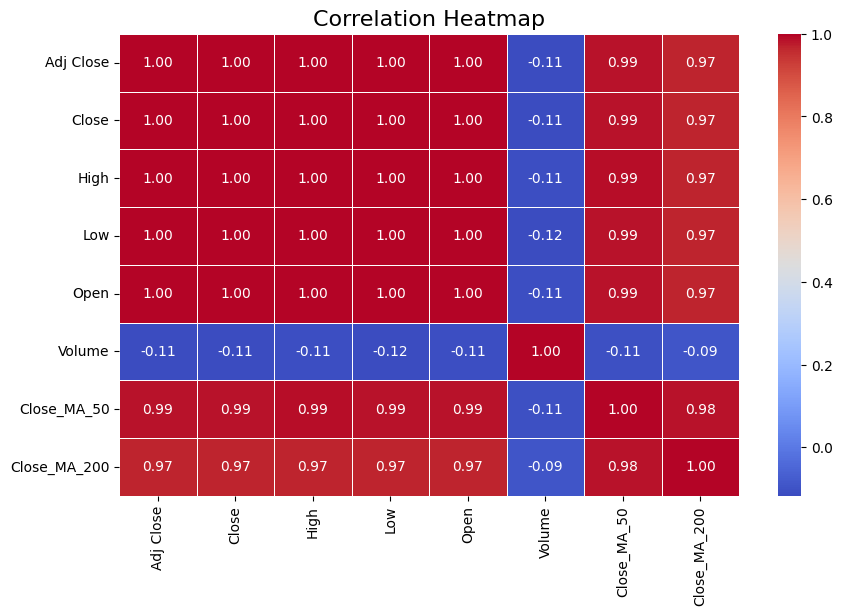

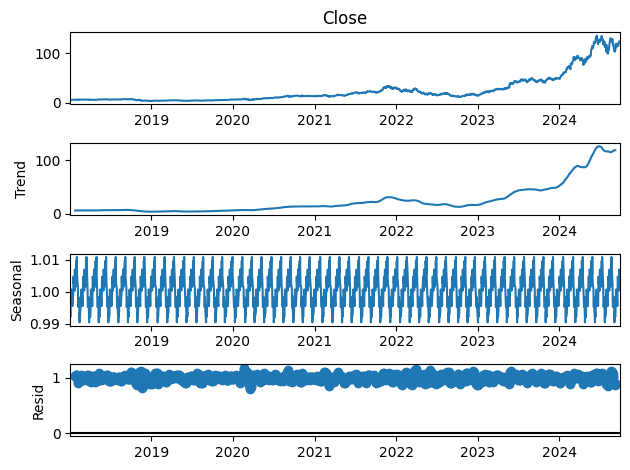


ADF Test Results:
ADF Statistic: 1.6381202033911526
p-value: 0.997967550949341
The time series is not stationary.
Epoch 1/20
41/41 [==============================] - 6s 52ms/step - loss: 9.9927e-04 - val_loss: 0.0034
Epoch 2/20
41/41 [==============================] - 2s 37ms/step - loss: 1.9202e-04 - val_loss: 9.5433e-04
Epoch 3/20
41/41 [==============================] - 1s 36ms/step - loss: 1.7309e-04 - val_loss: 9.7362e-04
Epoch 4/20
41/41 [==============================] - 2s 39ms/step - loss: 1.7096e-04 - val_loss: 0.0016
Epoch 5/20
41/41 [==============================] - 2s 39ms/step - loss: 1.6764e-04 - val_loss: 0.0010
Epoch 6/20
41/41 [==============================] - 2s 37ms/step - loss: 1.3530e-04 - val_loss: 9.3538e-04
Epoch 7/20
41/41 [==============================] - 2s 43ms/step - loss: 1.3393e-04 - val_loss: 9.5062e-04
Epoch 8/20
41/41 [==============================] - 2s 42ms/step - loss: 1.2523e-04 - val_loss: 8.0202e-04
Epoch 9/20
41/41 [=======================

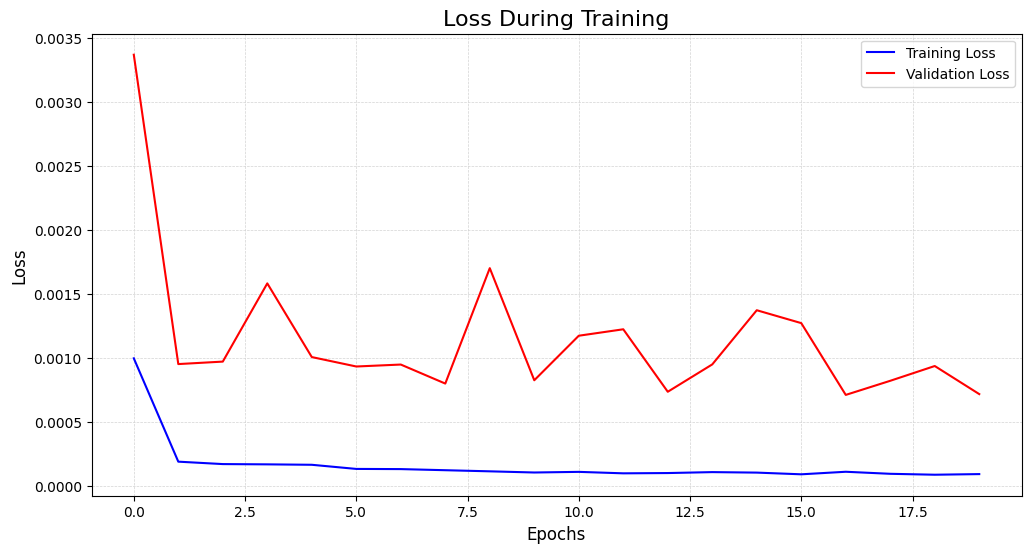

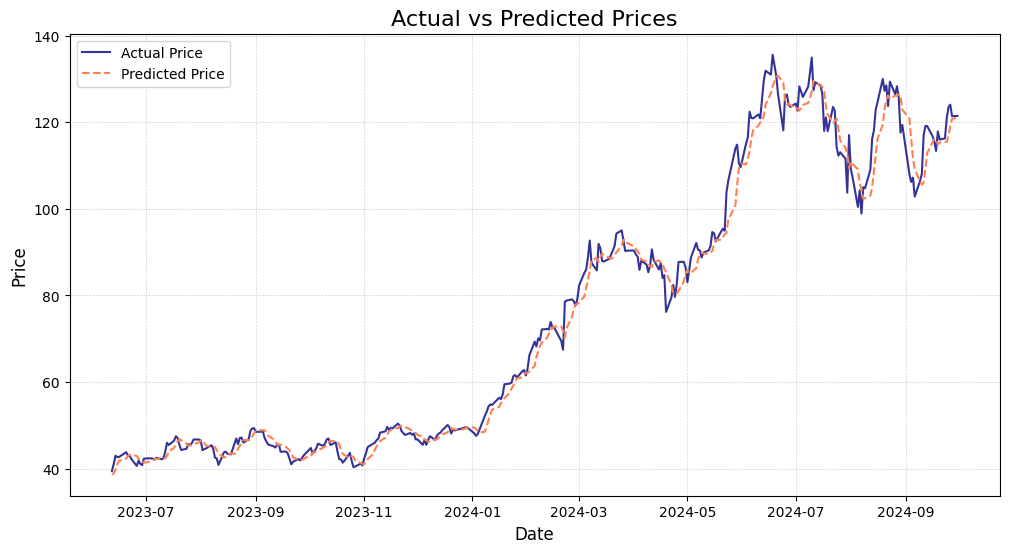

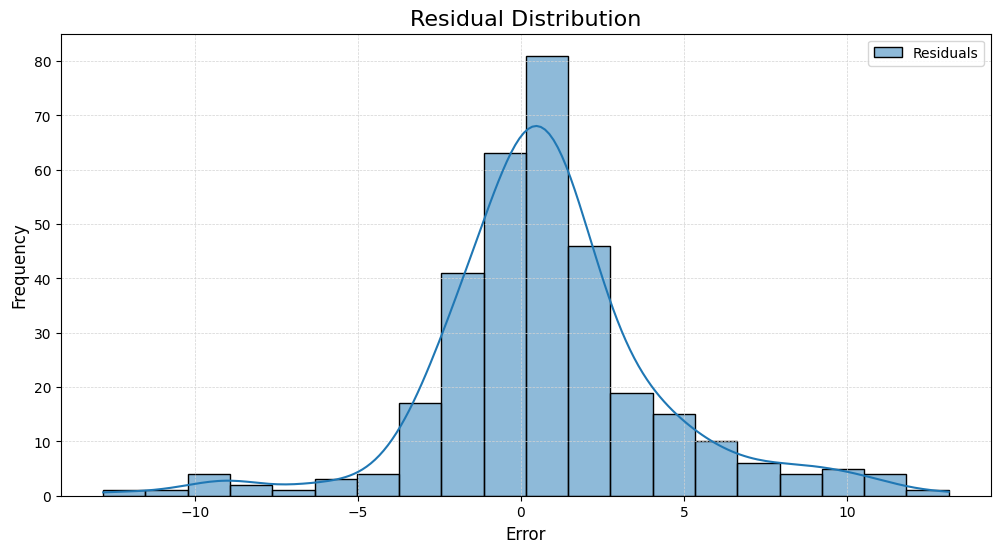

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from keras.models import Sequential
from keras.layers import GRU, Dense, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def analyze_and_forecast(file_path):
    # Load dataset
    data = pd.read_csv(file_path)
    data.columns = data.columns.str.strip()

    # Check and rename 'Price' column
    if 'Price' not in data.columns:
        print("Dataset columns:", data.columns)
        raise KeyError("Dataset must contain a 'Price' column for dates")
    data.rename(columns={'Price': 'Date'}, inplace=True)

    # Convert Date column to datetime and set as index
    data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
    data = data.dropna(subset=['Date'])
    data.set_index('Date', inplace=True)

    # Ensure numeric columns
    numeric_columns = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
    for col in numeric_columns:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors='coerce')
    data = data.dropna()

    # Exploratory Data Analysis
    print("\nDataset Info:")
    print(data.info())
    print("\nDataset Description:")
    print(data.describe())

    # 1. Closing Price Trends
    plt.figure(figsize=(12, 6))
    plt.plot(data.index, data['Close'], label='Close Price', color='teal')
    plt.title('Closing Price Over Time', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price', fontsize=12)
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.show()

    # 2. Moving Averages
    data['Close_MA_50'] = data['Close'].rolling(window=50).mean()
    data['Close_MA_200'] = data['Close'].rolling(window=200).mean()
    plt.figure(figsize=(12, 6))
    plt.plot(data.index, data['Close'], label='Close Price', color='blue', alpha=0.6)
    plt.plot(data.index, data['Close_MA_50'], label='50-Day MA', color='orange')
    plt.plot(data.index, data['Close_MA_200'], label='200-Day MA', color='green')
    plt.title('Moving Averages of Closing Prices', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price', fontsize=12)
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.show()

    # 3. Volume Trends
    plt.figure(figsize=(12, 6))
    plt.bar(data.index, data['Volume'], color='purple', alpha=0.5, label='Volume')
    plt.title('Volume Trends Over Time', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Volume', fontsize=12)
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.show()

    # 4. Correlation Heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Correlation Heatmap', fontsize=16)
    plt.show()

    # 5. Decompose Time Series
    decomposition = seasonal_decompose(data['Close'], model='multiplicative', period=30)
    decomposition.plot()
    plt.show()

    # 6. Stationarity Test
    result = adfuller(data['Close'])
    print("\nADF Test Results:")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    if result[1] < 0.05:
        print("The time series is stationary.")
    else:
        print("The time series is not stationary.")

    # Prepare data for GRU
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data[['Close']].values)

    sequence_length = 60
    X, y = [], []
    for i in range(sequence_length, len(scaled_data)):
        X.append(scaled_data[i-sequence_length:i])
        y.append(scaled_data[i, 0])

    X, y = np.array(X), np.array(y)

    # Split data
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # Build GRU model
    model = Sequential([
        GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1), activation='tanh'),
        Dropout(0.3),
        GRU(units=50, return_sequences=False, activation='tanh'),
        Dropout(0.3),
        Dense(units=1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Train the model
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)

    # Make predictions
    predictions = model.predict(X_test)
    predictions = scaler.inverse_transform(predictions)
    y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

    # Evaluation Metrics
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    print("\nEvaluation Metrics:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")

    # 7. Loss Graph
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
    plt.title('Loss During Training', fontsize=16)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.show()

    # 8. Actual vs Predicted Prices
    plt.figure(figsize=(12, 6))
    plt.plot(data.index[-len(y_test):], y_test, label='Actual Price', color='navy', alpha=0.8)
    plt.plot(data.index[-len(predictions):], predictions, label='Predicted Price', color='coral', linestyle='--')
    plt.title('Actual vs Predicted Prices', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price', fontsize=12)
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.show()

    # 9. Residual Distribution
    residuals = y_test - predictions
    plt.figure(figsize=(12, 6))
    sns.histplot(residuals, kde=True, color='orange', bins=20, label='Residuals')
    plt.title('Residual Distribution', fontsize=16)
    plt.xlabel('Error', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.show()

# Specify the file path
file_path = "NVIDIA_STOCK.csv"
analyze_and_forecast(file_path)


In [13]:
# Rename columns to match the expected structure
data.columns = ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

# Convert 'Date' to datetime format
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# Drop rows with invalid dates
data = data.dropna(subset=['Date'])

# Print updated column names and the first few rows
print("Updated Column Names:", data.columns)
print(data.head())


Updated Column Names: Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')
        Date           Adj Close               Close               High  \
2 2018-01-02   4.929879665374756   4.983749866485596  4.987500190734863   
3 2018-01-03   5.254334926605225  5.3117499351501465   5.34250020980835   
4 2018-01-04  5.2820329666137695   5.339749813079834  5.451250076293945   
5 2018-01-05   5.326793670654297   5.385000228881836  5.422749996185303   
6 2018-01-08   5.490012168884277   5.550000190734863              5.625   

                  Low               Open     Volume  
2   4.862500190734863  4.894499778747559  355616000  
3             5.09375  5.102499961853027  914704000  
4   5.317249774932861  5.394000053405762  583268000  
5  5.2769999504089355  5.354750156402588  580124000  
6  5.4644999504089355  5.510000228881836  881216000  


In [14]:
print("Minimum Date:", data['Date'].min())
print("Maximum Date:", data['Date'].max())


Minimum Date: 2018-01-02 00:00:00
Maximum Date: 2024-09-30 00:00:00


In [15]:
print("\nDataset Summary:")
print(data.describe())



Dataset Summary:
                       Date          Adj Close             Close  High  \
count                  1697               1697              1697  1697   
unique                 1697               1685              1674  1662   
top     2022-09-26 00:00:00  30.33582305908203  26.4950008392334  28.0   
freq                      1                  2                 2     3   
first   2018-01-02 00:00:00                NaN               NaN   NaN   
last    2024-09-30 00:00:00                NaN               NaN   NaN   

                      Low               Open     Volume  
count                1697               1697       1697  
unique               1672               1662       1695  
top     6.168749809265137  5.949999809265137  656912000  
freq                    3                  3          2  
first                 NaN                NaN        NaN  
last                  NaN                NaN        NaN  


/tmp/ipykernel_7002/701318163.py:2: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  print(data.describe())
